<a href="https://colab.research.google.com/github/martinpa-spec/Proyecto-Integrador-Henry-M5/blob/developer/Proyecto_Integrador_Avance_2_CrediPulse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrador - Avance 2: Ingeniería de Características y Modelamiento
**Autor:** Martín Pavón  
**Caso:** CrediPulse (Scoring de Crédito)  
**Objetivo:** Construir el pipeline de preprocesamiento de datos (v1.1.0) y entrenar/evaluar modelos supervisados de clasificación (v1.0.1).

In [20]:
# 1. Manejo de datos y tablas
import pandas as pd
import numpy as np

# 2. División de datos (Evita data leakage)
from sklearn.model_selection import train_test_split

# 3. Construcción de Pipelines y Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 4. Modelos de Clasificación Supervisada
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 5. Métricas de Evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Librerías importadas correctamente.")

df = pd.read_excel('Base_de_datos.xlsx')

# Mostrar dimensiones y las primeras 5 filas
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Librerías importadas correctamente.
Dimensiones del dataset: (10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


### Train / Test

In [21]:
#Declaracion de la columna target
target_col = "Pago_atiempo"

#Separacion en dos ejes, "y" para target y  "X" para dimensiones
X = df.drop(columns=[target_col, 'fecha_prestamo', 'puntaje'])
y = df[target_col]

#Codigo con ayuda de ia, armamos el split rapidamente de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Sugerencia IA: Mantiene la proporción de pagadores a tiempo y morosos
)
print(f"Tamaño X_train: {X_train.shape}")
print(f"Tamaño X_test:  {X_test.shape}")

Tamaño X_train: (8610, 20)
Tamaño X_test:  (2153, 20)


### Definicion del pipeline de Preprocesamiento

In [41]:
#Columnas por su tipo de dato
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Convertir explícitamente todas las variables categóricas a texto (str) en Train y Test
# para evitar mezclas de números y letras que rompan el OneHotEncoder
X_train[cat_cols] = X_train[cat_cols].astype(str)
X_test[cat_cols] = X_test[cat_cols].astype(str)

print(f"Columnas Numéricas ({len(num_cols)}): {num_cols}")
print(f"Columnas Categóricas ({len(cat_cols)}): {cat_cols}")

# 2. Pipeline Numérico
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Pipeline Categórico
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Integrar en el ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print("\nPipeline de Preprocesamiento ajustado correctamente.")

Columnas Numéricas (18): ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']
Columnas Categóricas (2): ['tipo_laboral', 'tendencia_ingresos']

Pipeline de Preprocesamiento ajustado correctamente.


Entreno y comparacion de modelos (CON SKLEARN)



In [44]:
#funcion para evaluar modelos
def evaluar_modelo(nombre_modelo, clasificador, X_tr, y_tr, X_te, y_te):
    pipeline_completo = Pipeline([
        ('preprocesamiento', preprocessor),
        ('modelo', clasificador)
    ])

    # Entrenar pipeline
    pipeline_completo.fit(X_tr, y_tr)

    # Predicciones
    y_pred = pipeline_completo.predict(X_te)

    # Probabilidades para ROC-AUC
    if hasattr(pipeline_completo, "predict_proba"):
        y_proba = pipeline_completo.predict_proba(X_te)[:, 1]
    else:
        y_proba = [0] * len(y_te)

    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1-Score": f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, y_proba)
    }

In [45]:
#modelos a comparar
modelos_a_evaluar = {
    "Regresión Logística": LogisticRegression(random_state=42, max_iter=1000),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 3. Iterar y guardar resultados
resultados = []
for nombre, algoritmo in modelos_a_evaluar.items():
    res = evaluar_modelo(nombre, algoritmo, X_train, y_train, X_test, y_test)
    resultados.append(res)

# 4. Mostrar la tabla comparativa ordenada por ROC-AUC
df_comparativa = pd.DataFrame(resultados).sort_values(by="ROC-AUC", ascending=False)
df_comparativa

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresión Logística,0.952624,0.952624,1.000000,0.975737,0.673885
2,Random Forest,0.952624,0.952624,1.000000,0.975737,0.627590
1,Árbol de Decisión,0.905248,0.953363,0.946855,0.950098,0.507741


In [46]:
%%writefile ft_engineering.py
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_feature_pipeline(X_train):
    """Crea el pipeline de preprocesamiento de características"""
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])

    return preprocessor

def prepare_data(filepath, target_col='Pago_atiempo'):
    """Carga el dataset, elimina leakage y retorna los conjuntos train/test"""
    df = pd.read_excel(filepath)
    X = df.drop(columns=[target_col, 'fecha_prestamo', 'puntaje'])
    y = df[target_col]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    cat_cols = X_tr.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    X_tr[cat_cols] = X_tr[cat_cols].astype(str)
    X_te[cat_cols] = X_te[cat_cols].astype(str)

    return X_tr, X_te, y_tr, y_te

Writing ft_engineering.py


### Metricas comparativas ROC-AUC entre modelos

/tmp/ipykernel_337/2725667087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparativa, x='Modelo', y='ROC-AUC', palette='Blues_d')


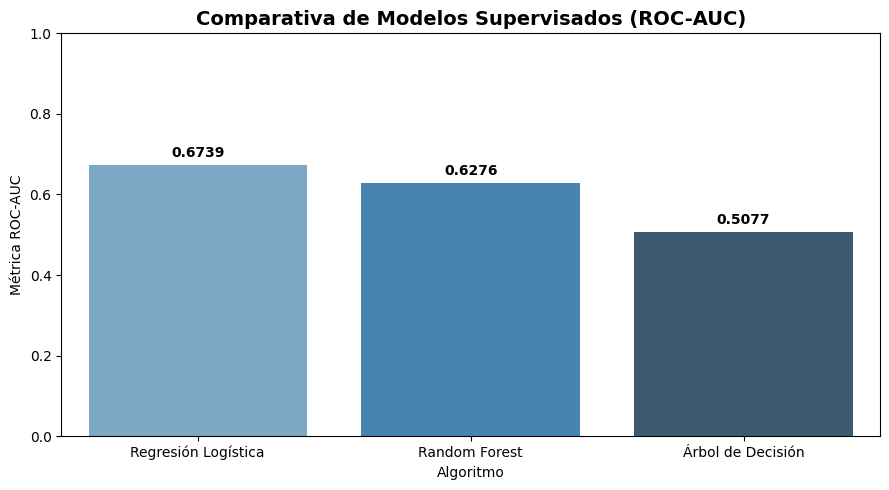

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear gráfico de barras comparando el ROC-AUC de los 3 modelos
plt.figure(figsize=(9, 5))
sns.barplot(data=df_comparativa, x='Modelo', y='ROC-AUC', palette='Blues_d')
plt.title('Comparativa de Modelos Supervisados (ROC-AUC)', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.ylabel('Métrica ROC-AUC')
plt.xlabel('Algoritmo')

# Poner el número exacto arriba de cada barra
for index, row in df_comparativa.reset_index().iterrows():
    plt.text(index, row['ROC-AUC'] + 0.02, f"{row['ROC-AUC']:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()